<a href="https://colab.research.google.com/github/aniketkumar112sonu-ui/fraud-detection-risk-engine/blob/main/notebook_03_fraud_detection_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fraud Detection & Risk Scoring System

## Problem Statement

The goal of this project is to build a machine learning system that identifies
fraudulent financial transactions from legitimate transactions.

The dataset is highly imbalanced, so the project focuses on detecting fraud
using appropriate evaluation metrics such as Precision, Recall, F1-score,
ROC-AUC and PR-AUC rather than relying on accuracy alone.

The final system will also generate a fraud probability and risk score for
each transaction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score)

In [3]:
df = pd.read_csv("/content/paysim dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


BASIC CLEANING

In [4]:
# Remove missing values
df = df.dropna().copy()

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

df = df.sort_values("step").reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape after cleaning: (6362620, 11)
Missing values: 0
Duplicate rows: 0


##  Time-Based Train / Validation / Test Split


In [5]:
# Sort by time
df = df.sort_values("step").reset_index(drop=True)

# Find split points
train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

# Chronological split
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["step"].min(), "→", train_df["step"].max())
print("Validation:", val_df["step"].min(), "→", val_df["step"].max())
print("Test:", test_df["step"].min(), "→", test_df["step"].max())

Train shape: (4453834, 11)
Validation shape: (954393, 11)
Test shape: (954393, 11)

Time ranges:
Train: 1 → 323
Validation: 323 → 378
Test: 378 → 743


## Feature Engineering

Creating transaction-level features to capture abnormal balance behavior.

In [6]:
def create_basic_features(data):
    data = data.copy()

    # Time features
    data["hour"] = data["step"] % 24
    data["day"] = data["step"] // 24
    data["is_night"] = ((data["hour"] >= 0) & (data["hour"] < 6)).astype(int)

    # Balance changes
    data["orig_balance_change"] = (
        data["oldbalanceOrg"] - data["newbalanceOrig"]
    )

    data["dest_balance_change"] = (
        data["newbalanceDest"] - data["oldbalanceDest"]
    )

    # Balance inconsistency
    data["orig_error"] = (
        data["amount"] - data["orig_balance_change"]
    )

    return data


train_df = create_basic_features(train_df)
val_df = create_basic_features(val_df)
test_df = create_basic_features(test_df)

### Account Transaction Frequency

In [7]:
# Calculate frequencies only from training data
orig_freq = train_df["nameOrig"].value_counts()
dest_freq = train_df["nameDest"].value_counts()

# Apply training-based frequencies to all datasets
train_df["orig_transaction_count"] = train_df["nameOrig"].map(orig_freq).fillna(0)
val_df["orig_transaction_count"] = val_df["nameOrig"].map(orig_freq).fillna(0)
test_df["orig_transaction_count"] = test_df["nameOrig"].map(orig_freq).fillna(0)

train_df["dest_transaction_count"] = train_df["nameDest"].map(dest_freq).fillna(0)
val_df["dest_transaction_count"] = val_df["nameDest"].map(dest_freq).fillna(0)
test_df["dest_transaction_count"] = test_df["nameDest"].map(dest_freq).fillna(0)

### Amount-Based Features

In [8]:
def create_amount_features(data):
    data = data.copy()

    # Log transformation of transaction amount
    data["amount_log"] = np.log1p(data["amount"])

    # Transaction amount relative to sender's balance
    data["amount_to_orig_balance"] = (
        data["amount"] / (data["oldbalanceOrg"] + 1)
    )

    # Transaction amount relative to receiver's balance
    data["amount_to_dest_balance"] = (
        data["amount"] / (data["oldbalanceDest"] + 1)
    )

    # Indicators for zero balances
    data["orig_balance_zero"] = (
        data["oldbalanceOrg"] == 0
    ).astype(int)

    data["dest_balance_zero"] = (
        data["oldbalanceDest"] == 0
    ).astype(int)

    return data


train_df = create_amount_features(train_df)
val_df = create_amount_features(val_df)
test_df = create_amount_features(test_df)

### Prepare Features for Modeling

In [9]:
# Separate target
X_train = train_df.drop(columns=["isFraud", "nameOrig", "nameDest"])
y_train = train_df["isFraud"]

X_val = val_df.drop(columns=["isFraud", "nameOrig", "nameDest"])
y_val = val_df["isFraud"]

X_test = test_df.drop(columns=["isFraud", "nameOrig", "nameDest"])
y_test = test_df["isFraud"]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

X_train: (4453834, 21)
X_val: (954393, 21)
X_test: (954393, 21)

Features:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'hour', 'day', 'is_night', 'orig_balance_change', 'dest_balance_change', 'orig_error', 'orig_transaction_count', 'dest_transaction_count', 'amount_log', 'amount_to_orig_balance', 'amount_to_dest_balance', 'orig_balance_zero', 'dest_balance_zero']


##  Preprocessing

In [10]:
# Identify feature types
categorical_features = ["type"]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['type']

Numerical features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'hour', 'day', 'is_night', 'orig_balance_change', 'dest_balance_change', 'orig_error', 'orig_transaction_count', 'dest_transaction_count', 'amount_log', 'amount_to_orig_balance', 'amount_to_dest_balance', 'orig_balance_zero', 'dest_balance_zero']


In [11]:
preprocessor = ColumnTransformer(
    transformers=[("num",StandardScaler(),numerical_features), ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)])

print("Preprocessor created successfully.")

Preprocessor created successfully.


## Class Imbalance

In [12]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentage:")
print(y_train.value_counts(normalize=True) * 100)

Training class distribution:
isFraud
0    4450191
1       3643
Name: count, dtype: int64

Training class percentage:
isFraud
0    99.918205
1     0.081795
Name: proportion, dtype: float64


## A Model Training

### A.1 Logistic Regression Baseline

Logistic Regression is used as an interpretable baseline model for binary fraud classification.

In [13]:
from sklearn.linear_model import LogisticRegression

In [14]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=100
    ))
])

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [15]:
# Predict fraud probabilities
y_val_proba = logistic_pipeline.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
y_val_pred = (y_val_proba >= 0.5).astype(int)

print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("PR-AUC:", average_precision_score(y_val, y_val_proba))

Precision: 0.026921576277799453
Recall: 0.9822064056939501
F1-score: 0.05240672173170037
ROC-AUC: 0.9980626226187006
PR-AUC: 0.5790226620261132


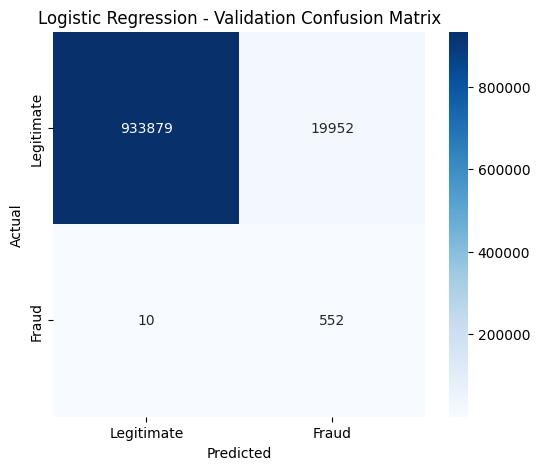

In [16]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()